In [98]:
# BMW_Sales_Data{2010 : 2024} // Analysis With Excel & Python // ML_Model

In [99]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Excel data
file_path = r"C:\Users\Karim\OneDrive\Desktop\Excel\BMW\BMW sales data (2010-2024).xlsx"
df = pd.read_excel(file_path)

# Display first 3 rows
print(df.head(3))

  Model  Year         Region  Color Fuel_Type Transmission  Engine_Size_L  \
0    i8  2010  South America  Black    Hybrid    Automatic            4.7   
1    i8  2010    Middle East   Grey    Petrol    Automatic            4.0   
2    X6  2010         Europe    Red    Hybrid       Manual            3.8   

   Mileage_KM  Price_USD  Sales_Volume Sales_Classification    Revenue  \
0       16020     102215          5006                  Low  511688290   
1       98514      37949          2278                  Low   86447822   
2      128477      68106          1048                  Low   71375088   

   Unnamed: 12  Unnamed: 13  Unnamed: 14        Sales_Volume.1 Unnamed: 16  \
0          NaN          NaN          NaN  Sales_Classification         MIN   
1          NaN          NaN          NaN                  7000        high   
2          NaN          NaN          NaN                   100         low   

         Sales_Volume.2 Unnamed: 18 Unnamed: 19  
0  Sales_Classification        

c:\Users\Karim\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
c:\Users\Karim\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Conditional Formatting extension is not supported and will be removed
  for idx, row in parser.parse():


In [100]:
# Drop Completely empty columns & duplicated
columns_to_drop = ['Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 16', 'Unnamed: 18', 'Unnamed: 19','Sales_Volume.1', 'Sales_Volume.2']
df_clean = df.drop(columns=columns_to_drop)

# Investigate & Handle the duplicates sales volume columns 
print("Actual duplicate rows:", df.duplicated().sum())

print("Cleaned dataset shape:", df_clean.shape)
print("\nCleaned columns:")
print(df_clean.columns.tolist())

Actual duplicate rows: 0
Cleaned dataset shape: (50000, 12)

Cleaned columns:
['Model', 'Year', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume', 'Sales_Classification', 'Revenue']


In [101]:
# Bacis Info About Data 
print(df_clean.info())
print(df_clean.describe()) # Summary Statistics (numerical columns)
print(df_clean.isnull().sum()) # Check for missing values 
print(df_clean.duplicated()) #Check for duplicaten 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
 11  Revenue               50000 non-null  int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 4.6+ MB
None
               Year  Engine_Size_L     Mileage_KM      Price_USD  \
count  50000.000000   50000.000000   50000

In [102]:
# Verify core data looks reasonable
print("Unique values in key columns:")
print("Models:", df_clean['Model'].nunique())
print("Years:", sorted(df_clean['Year'].unique()))
print("Price range:", df_clean['Price_USD'].min(), "-", df['Price_USD'].max())

Unique values in key columns:
Models: 11
Years: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Price range: 30000 - 119998


In [103]:
df_clean.to_excel(r"C:\Users\Karim\OneDrive\Desktop\Excel\BMW\BMW_cleaned.xlsx", index=False)
print("✅ Data exported successfully!")

✅ Data exported successfully!


In [104]:
df_clean = pd.read_excel(r"C:\Users\Karim\OneDrive\Desktop\Excel\BMW\BMW_cleaned.xlsx")
df_clean.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Revenue
0,i8,2010,South America,Black,Hybrid,Automatic,4.7,16020,102215,5006,Low,511688290
1,i8,2010,Middle East,Grey,Petrol,Automatic,4.0,98514,37949,2278,Low,86447822
2,X6,2010,Europe,Red,Hybrid,Manual,3.8,128477,68106,1048,Low,71375088
3,i8,2010,North America,White,Electric,Automatic,2.5,75457,101282,8396,High,850363672
4,X6,2010,Africa,Silver,Petrol,Manual,1.7,176650,33796,5935,Low,200579260


Model
7 Series    1790070249282
3 Series    1768534028214
i8          1764743448529
X1          1752985285361
5 Series    1735712423092
Name: Revenue, dtype: int64


C:\Users\Karim\AppData\Local\Temp\ipykernel_13920\1927507295.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_models.values, y= top_models.index, palette= "Blues_r",)


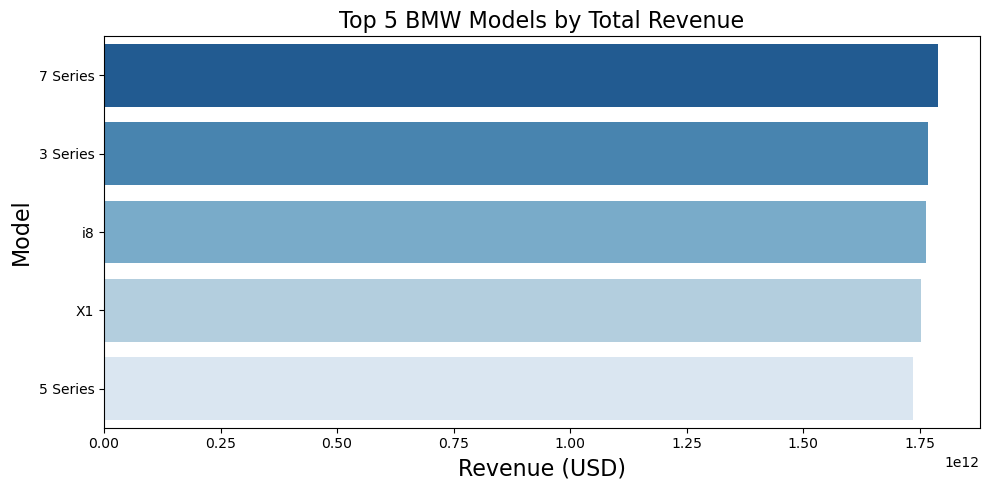

In [105]:
# Top 5 Models by Total Revenue
top_models = df_clean.groupby("Model")["Revenue"].sum().sort_values(ascending= False).head(5)
print(top_models)
plt.figure(figsize=(10, 5), dpi=100, tight_layout=True, facecolor='white', edgecolor='blue')
sns.barplot(x=top_models.values, y= top_models.index, palette= "Blues_r",)
plt.title("Top 5 BMW Models by Total Revenue", fontsize = 16)
plt.xlabel("Revenue (USD)",fontsize = 16)
plt.ylabel("Model",fontsize = 16)
plt.show()

Model
7 Series    23786466
i8          23423891
X1          23406060
3 Series    23281303
i3          23133849
5 Series    23097519
M5          22779688
X3          22745529
X5          22709749
X6          22661986
M3          22349694
Name: Sales_Volume, dtype: int64


C:\Users\Karim\AppData\Local\Temp\ipykernel_13920\2518324574.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_sales_volume.values, y= models_sales_volume.index, palette= "Blues_r",)


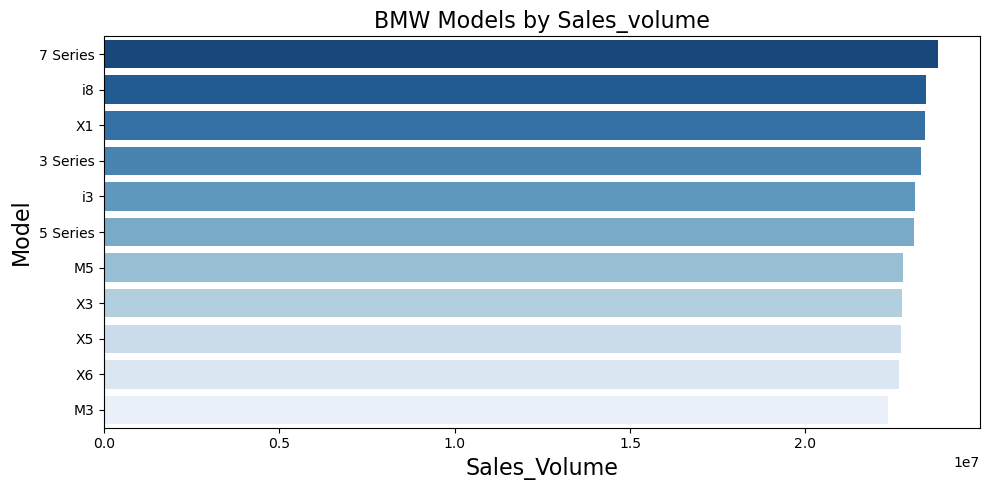

In [106]:
# BMW Models by Sales_volume
models_sales_volume = df_clean.groupby("Model")["Sales_Volume"].sum().sort_values(ascending= False)
print(models_sales_volume)
plt.figure(figsize=(10, 5), dpi=100, tight_layout=True, facecolor='white', edgecolor='blue')
sns.barplot(x=models_sales_volume.values, y= models_sales_volume.index, palette= "Blues_r",)
plt.title("BMW Models by Sales_volume", fontsize = 16)
plt.xlabel("Sales_Volume", fontsize = 16)
plt.ylabel("Model", fontsize = 16)
plt.show()

Fuel_Type
Electric    75276.313207
Diesel      75079.809671
Petrol      74990.419841
Hybrid      74797.551746
Name: Price_USD, dtype: float64


C:\Users\Karim\AppData\Local\Temp\ipykernel_13920\3273332338.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.index, y=avg_price.values, palette="Blues_r")


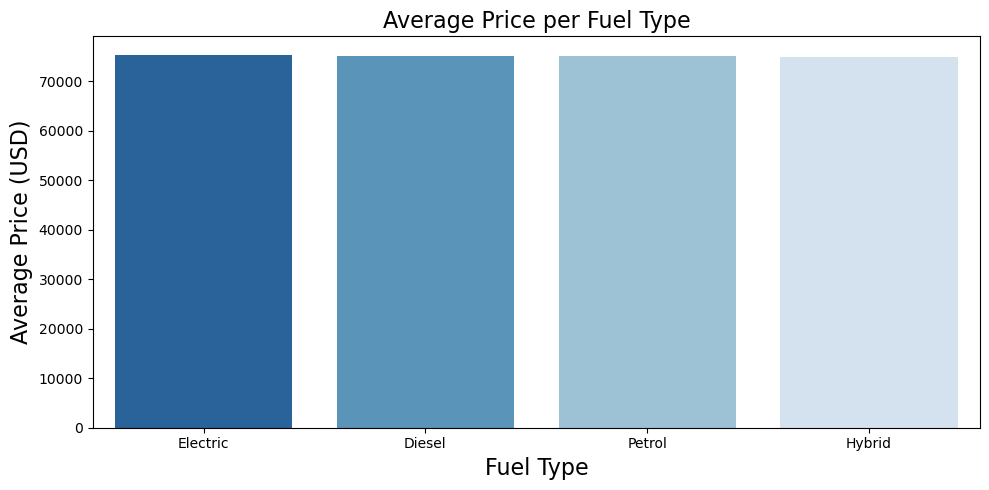

In [107]:
#Average Price by Fuel Type
avg_price = df_clean.groupby("Fuel_Type")["Price_USD"].mean().sort_values(ascending= False)
print(avg_price)
plt.figure(figsize=(10, 5), dpi=100, tight_layout=True, facecolor='white', edgecolor='blue')
sns.barplot(x=avg_price.index, y=avg_price.values, palette="Blues_r")
plt.title("Average Price per Fuel Type",fontsize = 16)
plt.ylabel("Average Price (USD)",fontsize = 16)
plt.xlabel("Fuel Type",fontsize = 16)
plt.show()

Year
2010    16933445
2011    16758941
2012    16751895
2013    16866733
2014    16958960
2015    17010207
2016    16957550
2017    16620811
2018    16412273
2019    17191956
2020    16310843
2021    16884666
2022    17920946
2023    16268654
2024    17527854
Name: Sales_Volume, dtype: int64


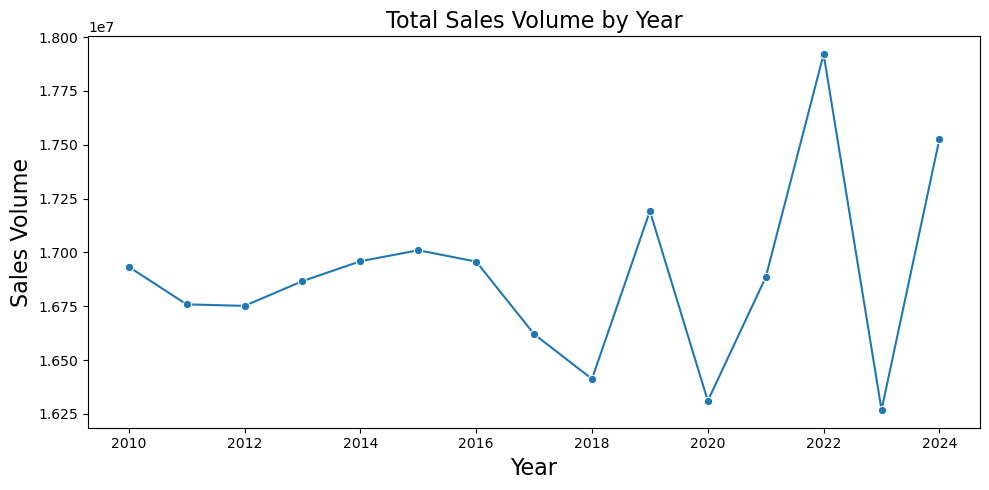

In [108]:
#Sales Trend Over Time (Yearly)
sales_trend = df.groupby("Year")["Sales_Volume"].sum()
print(sales_trend)
plt.figure(figsize=(10, 5), dpi=100, tight_layout=True, facecolor='white', edgecolor='blue')
sns.lineplot(x=sales_trend.index, y=sales_trend.values, marker='o')
plt.title("Total Sales Volume by Year",fontsize = 16)
plt.xlabel("Year",fontsize = 16)
plt.ylabel("Sales Volume",fontsize = 16)
plt.show()

Region
Asia             3250635961348
Europe           3188079573212
North America    3182938635076
Middle East      3167783530851
South America    3113805414620
Africa           3108999419352
Name: Revenue, dtype: int64


C:\Users\Karim\AppData\Local\Temp\ipykernel_13920\1665040273.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Region_Revenue.index, y=Region_Revenue.values, palette="Blues_r")


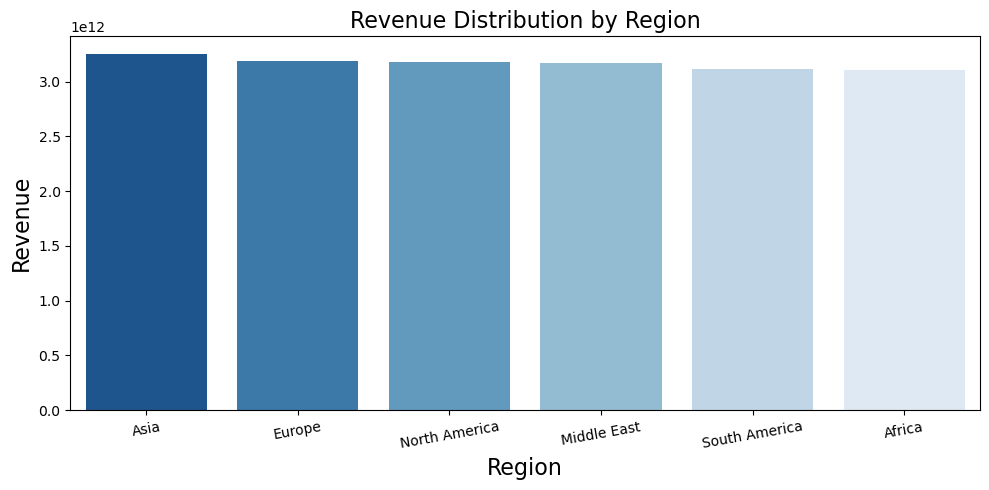

In [109]:
# Revenue By Region
Region_Revenue = df.groupby("Region")["Revenue"].sum().sort_values(ascending= False)
print(Region_Revenue)
plt.figure(figsize=(10, 5), dpi=100, tight_layout=True, facecolor='white', edgecolor='blue')
sns.barplot(x=Region_Revenue.index, y=Region_Revenue.values, palette="Blues_r")
plt.title("Revenue Distribution by Region",fontsize = 16)
plt.xlabel("Region", fontsize = 16)
plt.ylabel("Revenue", fontsize= 16)
plt.xticks(rotation=10)
plt.show()

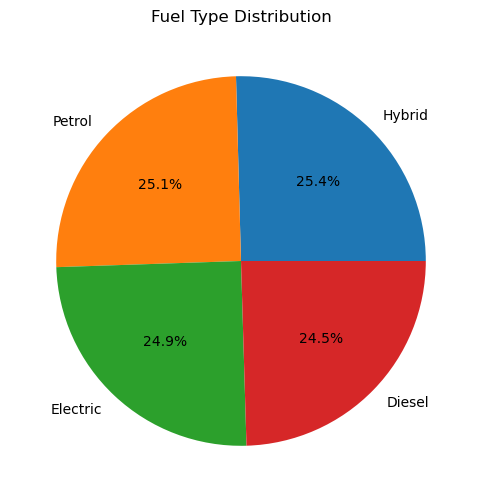

In [110]:
# Fuel_Type Pie 
plt.figure(figsize=(6,6))
df_clean['Fuel_Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Fuel Type Distribution')
plt.ylabel('')
plt.show()


In [111]:

#summary = {
#    "Top_Models": top_models,
#    "models_sales_volume" : models_sales_volume,
#    "Region_Revenue": Region_Revenue,
#    "Avg_Price_Fuel": avg_price,
#    "Sales_Trend": sales_trend}

#with pd.ExcelWriter("BMW_insights.xlsx") as writer:
#    for name, data in summary.items():
#        data.to_excel(writer, sheet_name=name)

In [112]:
# KPIs
total_revenue = df_clean["Revenue"].sum() # Total revenue across all sales
total_sales = df_clean["Sales_Volume"].sum() # Total cars sold
fuel_type = df_clean['Fuel_Type'].value_counts() # How many cars per type
avg_price = df_clean['Price_USD'].mean() # Average car price
avg_price_region = df_clean.groupby('Region')['Price_USD'].mean() # Average Price by Region
avg_engine = df_clean['Engine_Size_L'].mean() # Average engine size
# Summary table
kpi_summary = pd.DataFrame({
    'Metric':['Total Revenue', 'Total Sales Volume', 'Average Price (USD)', 'Average Engine Size (L)'],
    'Value': [total_revenue, total_sales, avg_price, avg_engine]
})

print("KPI Summary:\n",kpi_summary)
print("Avrage Price By Region:\n",avg_price_region)
print("Fuel Type Breakdown:\n", fuel_type)

KPI Summary:
                     Metric         Value
0            Total Revenue  1.901224e+13
1       Total Sales Volume  2.533757e+08
2      Average Price (USD)  7.503460e+04
3  Average Engine Size (L)  3.247180e+00
Avrage Price By Region:
 Region
Africa           74885.771598
Asia             75554.925006
Europe           74988.356851
Middle East      74726.788487
North America    75070.054709
South America    74973.598837
Name: Price_USD, dtype: float64
Fuel Type Breakdown:
 Fuel_Type
Hybrid      12716
Petrol      12550
Electric    12471
Diesel      12263
Name: count, dtype: int64


In [113]:
#with pd.ExcelWriter("BMW_Automated_Report.xlsx") as writer:
#    for name, data in summary.items():
#       data.to_excel(writer, sheet_name=name
#    df_clean.to_excel(writer, sheet_name='Cleaned_Data', index=False)
#    kpi_summary.to_excel(writer, sheet_name='KPIs', index=False)

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

In [115]:
non_numeric_data = ['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Sales_Classification']

for i in non_numeric_data:
    LE = LabelEncoder()
    df_clean[i] = LE.fit_transform(df_clean[i])

In [116]:
X = df_clean.drop(['Sales_Classification'], axis='columns')
y = df_clean['Sales_Classification']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=52
)

In [117]:
decision_tree = DecisionTreeClassifier(random_state=500, max_depth=10)
decision_tree.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(decision_tree.score(X_train, y_train)))
print("Accuracy on testing set: {:.3f}".format(decision_tree.score(X_test, y_test)))

Accuracy on training set: 1.000
Accuracy on testing set: 1.000


In [118]:
random_forest = RandomForestClassifier(random_state=52, max_depth=9)
random_forest.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(random_forest.score(X_train, y_train)))
print("Accuracy on testing set: {:.3f}".format(random_forest.score(X_test, y_test)))

Accuracy on training set: 1.000
Accuracy on testing set: 1.000


In [119]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [120]:
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.2f}".format(knn.score(X_train_scaled, y_train)))
print("Accuracy on testing set: {:.2f}".format(knn.score(X_test_scaled, y_test)))

Accuracy on training set: 0.96
Accuracy on testing set: 0.91
Accuracy on testing set: 0.91


In [121]:
scaler = StandardScaler()
X_train_nscaled = scaler.fit_transform(X_train)
X_test_nscaled = scaler.fit_transform(X_test)

In [122]:
mlp = MLPClassifier(solver='adam', activation='relu', hidden_layer_sizes=[100, 50], max_iter=500)
mlp.fit(X_train_nscaled, y_train)
print("MLP Accuracy on training set: {:.3f}".format(mlp.score(X_train_scaled, y_train)))
print("MLP Accuracy on testing set: {:.3f}".format(mlp.score(X_test_scaled, y_test)))

MLP Accuracy on training set: 0.858
MLP Accuracy on testing set: 0.861


In [123]:
import joblib
import pickle
import pandas as pd
from datetime import datetime
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Save the KNN model
joblib.dump(knn, 'bmw_sales_classifier_knn.pkl')

# Save the scaler (MinMaxScaler that you used for KNN)
joblib.dump(scaler, 'knn_scaler.pkl')  # Your MinMaxScaler from previous code

# Save label encoders for categorical features
label_encoders = {}
categorical_columns = ['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Sales_Classification']

for col in categorical_columns:
    if col in df_clean.columns:
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col])
        label_encoders[col] = le

# Save label encoders
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print(" KNN Model and preprocessors saved successfully!")
print(f" Files saved: bmw_sales_classifier_knn.pkl, knn_scaler.pkl, label_encoders.pkl")

 KNN Model and preprocessors saved successfully!
 Files saved: bmw_sales_classifier_knn.pkl, knn_scaler.pkl, label_encoders.pkl


In [124]:
class BMWSalesKNNPredictor:
    def __init__(self):
        self.model = None
        self.scaler = None
        self.label_encoders = None
        self.feature_columns = None
        
    def load_model(self, model_path='bmw_sales_classifier_knn.pkl', 
                   scaler_path='knn_scaler.pkl', 
                   encoder_path='label_encoders.pkl'):
        """Load the trained KNN model and preprocessors"""
        try:
            self.model = joblib.load(model_path)
            self.scaler = joblib.load(scaler_path)
            with open(encoder_path, 'rb') as f:
                self.label_encoders = pickle.load(f)
            
            # Define feature columns (same as training)
            self.feature_columns = ['Model', 'Year', 'Region', 'Color', 'Fuel_Type', 
                                   'Transmission', 'Engine_Size_L', 'Mileage_KM', 
                                   'Price_USD', 'Sales_Volume', 'Revenue']
            print(" KNN Model loaded successfully!")
            
        except Exception as e:
            print(f"❌ Error loading model: {e}")
        
    def preprocess_input(self, input_data):
        """Preprocess new input data same as training data"""
        # Create a copy
        processed_data = input_data.copy()
        
        # Encode categorical variables
        for col in ['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission']:
            if col in processed_data.columns:
                # Handle unseen labels
                unique_values = set(processed_data[col].unique())
                trained_classes = set(self.label_encoders[col].classes_)
                
                for value in unique_values:
                    if value not in trained_classes:
                        # Replace unseen labels with most frequent
                        most_frequent = self.label_encoders[col].classes_[0]
                        processed_data[col] = processed_data[col].replace(value, most_frequent)
                        print(f"⚠️  Replaced unseen label '{value}' with '{most_frequent}' in column '{col}'")
                
                processed_data[col] = self.label_encoders[col].transform(processed_data[col])
        
        # Ensure correct column order
        processed_data = processed_data[self.feature_columns]
        
        # Scale numerical features using the same scaler used for KNN
        if self.scaler:
            processed_data = self.scaler.transform(processed_data)
            
        return processed_data
    
    def predict(self, input_data):
        """Make predictions on new data"""
        if self.model is None:
            self.load_model()
        
        processed_data = self.preprocess_input(input_data)
        predictions = self.model.predict(processed_data)
        
        # Decode predictions back to original labels
        decoded_predictions = self.label_encoders['Sales_Classification'].inverse_transform(predictions)
        
        return decoded_predictions
    
    def predict_proba(self, input_data):
        """Get prediction probabilities"""
        if self.model is None:
            self.load_model()
            
        processed_data = self.preprocess_input(input_data)
        probabilities = self.model.predict_proba(processed_data)
        
        return probabilities
    
    def get_class_labels(self):
        """Get the class labels from the encoder"""
        return self.label_encoders['Sales_Classification'].classes_

# Initialize KNN predictor
knn_predictor = BMWSalesKNNPredictor()
knn_predictor.load_model()

 KNN Model loaded successfully!


In [125]:
# Create sample new data for testing
sample_data = pd.DataFrame({
    'Model': ['3 Series', '7 Series', 'X5'],
    'Year': [2023, 2024, 2022],
    'Region': ['Europe', 'North America', 'Asia'],
    'Color': ['Black', 'White', 'Grey'],
    'Fuel_Type': ['Hybrid', 'Electric', 'Petrol'],
    'Transmission': ['Automatic', 'Automatic', 'Manual'],
    'Engine_Size_L': [2.0, 3.0, 2.5],
    'Mileage_KM': [15000, 5000, 30000],
    'Price_USD': [65000, 95000, 55000],
    'Sales_Volume': [1000, 500, 2000],
    'Revenue': [65000000, 47500000, 110000000]
})

print(" Testing KNN Model Deployment with Sample Data:")
print("=" * 50)

# Ensure column names match the training data
sample_data.rename(columns={'Engine_size_L': 'Engine_Size_L'}, inplace=True)

# Make predictions
predictions = knn_predictor.predict(sample_data)
probabilities = knn_predictor.predict_proba(sample_data)
class_labels = knn_predictor.get_class_labels()

print(f"Available classes: {class_labels}")

# Create detailed results dataframe
results = sample_data.copy()
results['Predicted_Classification'] = predictions
results['Prediction_Confidence'] = probabilities.max(axis=1)

# Add probability for each class
for i, class_label in enumerate(class_labels):
    results[f'Prob_{class_label}'] = probabilities[:, i]

print("\n Prediction Results:")
print("=" * 50)
display_results = results[['Model', 'Year', 'Region', 'Predicted_Classification', 
                          'Prediction_Confidence']].copy()
print(display_results)

print("\n Detailed Probabilities:")
print("=" * 50)
for idx, row in results.iterrows():
    print(f"\n{row['Model']} ({row['Year']}):")
    print(f"  Prediction: {row['Predicted_Classification']}")
    print(f"  Confidence: {row['Prediction_Confidence']:.2%}")
    for class_label in class_labels:
        prob = row[f'Prob_{class_label}']
        print(f"  {class_label}: {prob:.2%}")

# Test model performance
print(f"\n KNN Model Test Accuracy: {knn.score(X_test_scaled, y_test):.2%}")

 Testing KNN Model Deployment with Sample Data:
⚠️  Replaced unseen label 'X5' with '0' in column 'Model'
⚠️  Replaced unseen label '3 Series' with '0' in column 'Model'
⚠️  Replaced unseen label '7 Series' with '0' in column 'Model'
⚠️  Replaced unseen label 'Asia' with '0' in column 'Region'
⚠️  Replaced unseen label 'North America' with '0' in column 'Region'
⚠️  Replaced unseen label 'Europe' with '0' in column 'Region'
⚠️  Replaced unseen label 'White' with '0' in column 'Color'
⚠️  Replaced unseen label 'Black' with '0' in column 'Color'
⚠️  Replaced unseen label 'Grey' with '0' in column 'Color'
⚠️  Replaced unseen label 'Electric' with '0' in column 'Fuel_Type'
⚠️  Replaced unseen label 'Petrol' with '0' in column 'Fuel_Type'
⚠️  Replaced unseen label 'Hybrid' with '0' in column 'Fuel_Type'
⚠️  Replaced unseen label 'Manual' with '0' in column 'Transmission'
⚠️  Replaced unseen label 'Automatic' with '0' in column 'Transmission'
⚠️  Replaced unseen label 'X5' with '0' in column

C:\Users\Karim\AppData\Local\Temp\ipykernel_13920\2473787009.py:43: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  processed_data[col] = processed_data[col].replace(value, most_frequent)
C:\Users\Karim\AppData\Local\Temp\ipykernel_13920\2473787009.py:43: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  processed_data[col] = processed_data[col].replace(value, most_frequent)
C:\Users\Karim\AppData\Local\Temp\ipykernel_13920\2473787009.py:43: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future v


 KNN Model Test Accuracy: 90.61%
